<center> <h2><b>2 Supervised Learning</b></h2> </center>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import importlib
import sys
sys.path.append("..")  # Ensure the parent directory is in the path

from data_parsing.data_parsing import parse_data, extract_labels
import visualization.data_exploration_plots
import data_preprocessing.data_preprocessing
import models.classic_ml.classic_ml_models

# Reload the module to reflect changes
importlib.reload(visualization.data_exploration_plots)
importlib.reload(data_preprocessing.data_preprocessing)
importlib.reload(models.classic_ml.classic_ml_models)

from visualization.data_exploration_plots import *
from data_preprocessing.data_cleaning import *
from data_preprocessing.data_preprocessing import *
from models.classic_ml.classic_ml_models import *

from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression, mutual_info_regression, SelectFromModel
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import Lasso, LassoCV, Ridge, RidgeCV, LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RationalQuadratic
from sklearn.svm import SVR
from sklearn.ensemble import IsolationForest, StackingRegressor, GradientBoostingRegressor, ExtraTreesRegressor, AdaBoostRegressor
from sklearn.model_selection import cross_val_score

In [2]:
# Read the parsed data saved as parquet files
X_set_a, X_set_b, X_set_c = pd.read_parquet('set-a.parquet'), pd.read_parquet('set-b.parquet'), pd.read_parquet('set-c.parquet')
Y_set_a, Y_set_b, Y_set_c = pd.read_parquet('outcomes-a.parquet'), pd.read_parquet('outcomes-b.parquet'), pd.read_parquet('outcomes-c.parquet')

# From X_set_c drop unnamed parameter column
X_set_c = X_set_c.drop(columns='')

In [3]:
X_set_a = clean_data(X_set_a)
X_set_b = clean_data(X_set_b)
X_set_c = clean_data(X_set_c)

X_train = X_set_a
X_valid = X_set_b
X_test = X_set_c

y_train = np.array(Y_set_a.drop(columns=['recordid'])).ravel()
y_valid = np.array(Y_set_b.drop(columns=['recordid'])).ravel()
y_test = np.array(Y_set_c.drop(columns=['recordid'])).ravel()

In [4]:
X_train.shape

(196000, 43)

In [5]:
X_train.head(2)

,recordid,time,ALP,ALT,AST,Age,Albumin,BUN,Bilirubin,Cholesterol,...,RespRate,SaO2,SysABP,Temp,TroponinI,TroponinT,Urine,WBC,Weight,pH
0,132539,00:00,NaN,NaN,NaN,54,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,132539,01:00,NaN,NaN,NaN,54,NaN,NaN,NaN,NaN,...,19.0,NaN,NaN,35.6,NaN,NaN,60.0,NaN,NaN,NaN


## Q2.1 Classic Machine Learning Methods - Random Forest and Logistic Regression

### 2.1.1 Basic Feature engineering

In [6]:
X_train_mean, X_valid_mean, X_test_mean = prepare_data_basic_for_ML_classifier(X_train, X_valid, X_test, method="mean")

X_train_max, X_valid_max, X_test_max = prepare_data_basic_for_ML_classifier(X_train, X_valid, X_test, method="max")

X_train_last_measured, X_valid_last_measured, X_test_last_measured = prepare_data_basic_for_ML_classifier(X_train, X_valid, X_test, method="last")

Training and Evaluating LR Models: 100%|██████████| 3/3 [00:00<00:00,  7.27dataset/s]


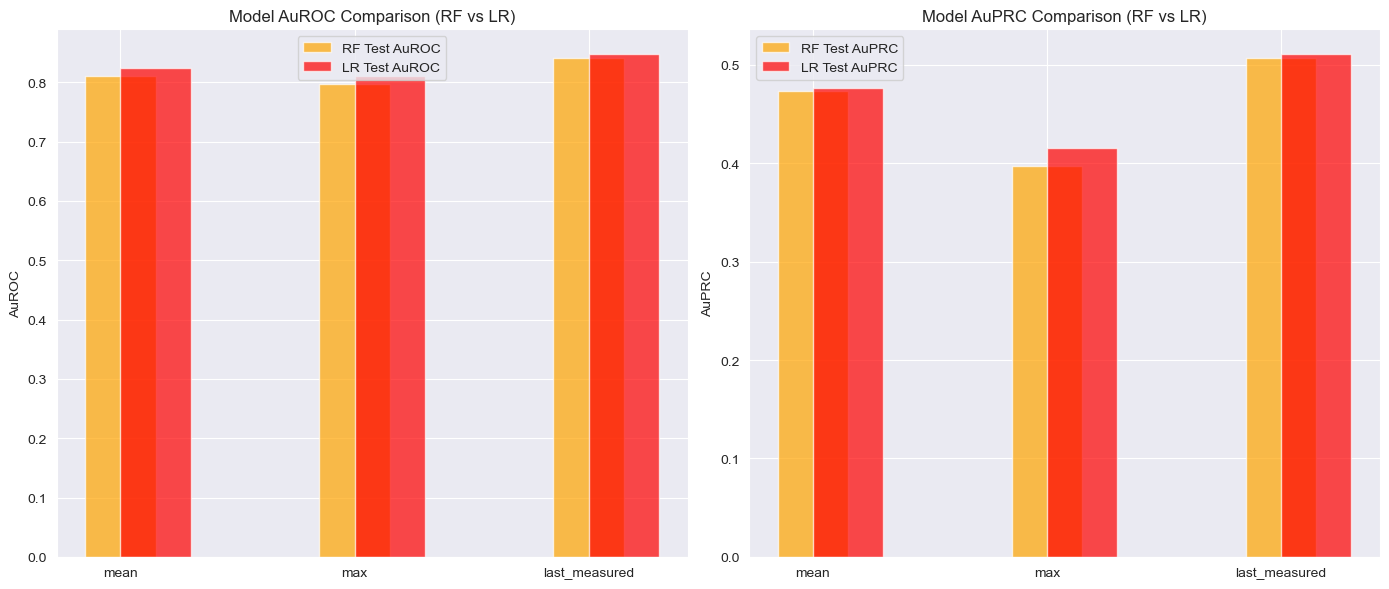

In [7]:
# Dictionary of X datasets (mean, max, last_measured)
X_train_dict = {
    'mean': X_train_mean,
    'max': X_train_max,
    'last_measured': X_train_last_measured
}

X_valid_dict = {
    'mean': X_valid_mean,
    'max': X_valid_max,
    'last_measured': X_valid_last_measured
}

X_test_dict = {
    'mean': X_test_mean,
    'max': X_test_max,
    'last_measured': X_test_last_measured
}

# Train and evaluate both models (Random Forest and Logistic Regression)
datasets = ['mean', 'max', 'last_measured']

# Random Forest Results
results_rf = train_and_evaluate_for_datasets(datasets, 'rf', X_train_dict, X_valid_dict, X_test_dict, y_train, y_valid, y_test)

# Logistic Regression Results
results_lr = train_and_evaluate_for_datasets(datasets, 'lr', X_train_dict, X_valid_dict, X_test_dict, y_train, y_valid, y_test)

# Plot the performance comparison for both models
plot_performance_comparison(results_rf, results_lr)

In [8]:
results_rf

{'mean': {'test_auroc': 0.8108670896372214, 'test_auprc': 0.4727751878006678},
 'max': {'test_auroc': 0.7964335323046889, 'test_auprc': 0.3973155123600175},
 'last_measured': {'test_auroc': 0.8403323697613595,
  'test_auprc': 0.5067660317798343}}

In [9]:
results_lr

{'mean': {'test_auroc': 0.8235707224287019, 'test_auprc': 0.47591780210469736},
 'max': {'test_auroc': 0.8109181464379123, 'test_auprc': 0.4148701580275069},
 'last_measured': {'test_auroc': 0.8470258162205453,
  'test_auprc': 0.5103587425922544}}

### 2.1.2 More advanced feature engineering

In [10]:
X_train_advanced, X_valid_advanced, X_test_advanced = prepare_data_advanced_for_ML_classifier(X_train, X_valid, X_test)

In [11]:
results_rf_advanced = train_and_evaluate_model('rf', X_train_advanced, X_valid_advanced, X_test_advanced, y_train, y_valid, y_test)

In [12]:
results_lr_advanced = train_and_evaluate_model('lr', X_train_advanced, X_valid_advanced, X_test_advanced, y_train, y_valid, y_test)

In [13]:
results_rf_advanced

{'validation': {'auroc': 0.8396822880757739, 'auprc': 0.511083883791051},
 'test': {'auroc': 0.8429062331844177, 'auprc': 0.522367815543228}}

In [14]:
results_lr_advanced

{'validation': {'auroc': 0.8478615721133326, 'auprc': 0.5215173009103039},
 'test': {'auroc': 0.8474808224149365, 'auprc': 0.504807461812384}}